# 35 — Peripheral Attention Index (PAI) Census

**Rank-type tag: `typed_gapfill`. Regime: `[LAB]`.**

Implements Duchowski, Gehrer & Svaldi's Peripheral Attention Index on the
AdSERP corpus. PAI replaces unary AOI assignment (in-the-box-or-not) with a
soft membership: opacity 1 inside the AOI, smooth parameter-free decay
outside, normalized by the ratio of Object-Gaze Distance (OGD) to
Centroid-Gaze Distance (OCD) so the peripheral skirt scales with each AOI's
own extent.

**Documented assumptions (abstract-only implementation — paper in review):**
1. **Functional form:** α = clip(1 − OGD/OCD, 0, 1). Reproduces every property
   the abstract claims (opaque inside since OGD=0; smooth decay; automatic
   size/shape adaptation; parameter-free). The published form may differ by a
   monotone reshaping (e.g., an exponent); rank-based census results are
   invariant to that, absolute α values are not.
2. **OGD distance target:** abstract says "minimum distance to any AOI
   *vertex*". For dense polygonal AOIs (their body-pose meshes) vertex ≈
   boundary; for our sparse 4-corner rectangles the two diverge badly (a gaze
   point beside the midpoint of a 586-px-wide snippet edge is ~300 px from
   every vertex but ~0 px from the AOI). Primary implementation uses
   **boundary (edge) distance**; vertex distance is run as a sensitivity
   variant. The divergence is a technical question to raise with Duchowski.

**Questions:**
- **Q1 (discard census):** what fraction of fixations does unary assignment
  drop entirely, and how many of those carry substantial soft membership?
- **Q2 (peripheral influence matrix):** for fixations hard-assigned to type A,
  how much soft mass lands on neighboring type B — e.g., ad exposure during
  organic reading with zero ad fixations? (AllSERP enrichment-column preview.)
- **Q3 (NB33 robustness):** do NB33's census values (organic leftward 40.2%,
  Gate A type ordering) survive soft assignment?


In [1]:
import json, glob
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
FIX_DIR = ROOT / 'AdSERP' / 'data' / 'fixation-coords'
AOI_DIR = ROOT / 'data' / 'aoi-typed-gapfill'

THETA = 40
MAX_GAP_MS = 1000
SWEEP_FRAC = 0.5
ALPHA_FLOOR = 0.05      # ignore memberships below this in census bookkeeping

def load_aois(tid):
    out = []
    for i, a in enumerate(json.load(open(AOI_DIR / f'{tid}.json'))):
        if any(a.get(k) is None for k in ('x', 'y', 'width', 'height')):
            continue
        a['idx'] = i
        a['cx'] = a['x'] + a['width'] / 2.0
        a['cy'] = a['y'] + a['height'] / 2.0
        out.append(a)
    return out

def ogd_boundary(px, py, a):
    """Distance from point to rectangle boundary region (0 inside)."""
    dx = max(a['x'] - px, 0.0, px - (a['x'] + a['width']))
    dy = max(a['y'] - py, 0.0, py - (a['y'] + a['height']))
    return (dx * dx + dy * dy) ** 0.5

def ogd_vertex(px, py, a):
    """Literal abstract form: min distance to the 4 rectangle vertices."""
    vs = ((a['x'], a['y']), (a['x'] + a['width'], a['y']),
          (a['x'], a['y'] + a['height']), (a['x'] + a['width'], a['y'] + a['height']))
    return min(((px - vx) ** 2 + (py - vy) ** 2) ** 0.5 for vx, vy in vs)

def pai(px, py, a, ogd_fn=ogd_boundary):
    ogd = ogd_fn(px, py, a)
    if ogd == 0.0 and ogd_fn is ogd_boundary:
        return 1.0
    ocd = ((px - a['cx']) ** 2 + (py - a['cy']) ** 2) ** 0.5
    if ocd <= 0:
        return 1.0
    return float(np.clip(1.0 - ogd / ocd, 0.0, 1.0))

trials = sorted(set(p.stem for p in FIX_DIR.glob('*.json'))
                & set(p.stem for p in AOI_DIR.glob('*.json')))
print(f'trials: {len(trials)}')


trials: 2776


In [2]:
# ── Corpus pass: per-fixation hard assignment + soft membership vector ──
fix_rows = []            # (trial, i, dur, hard_type or None, {aoi_idx: alpha}, {aoi_idx: alpha_vertex})
aoi_type = {}            # (trial, idx) -> type
for tid in trials:
    aois = load_aois(tid)
    for a in aois:
        aoi_type[(tid, a['idx'])] = a['type']
    fixes = json.load(open(FIX_DIR / f'{tid}.json'))
    for i, fx in enumerate(fixes):
        px, py = fx['x'], fx['y']
        hard, hard_area = None, None
        soft, softv = {}, {}
        for a in aois:
            al = pai(px, py, a)
            if al >= ALPHA_FLOOR:
                soft[a['idx']] = al
            av = pai(px, py, a, ogd_vertex)
            if av >= ALPHA_FLOOR:
                softv[a['idx']] = av
            if a['x'] <= px <= a['x'] + a['width'] and a['y'] <= py <= a['y'] + a['height']:
                ar = a['width'] * a['height']
                if hard is None or ar < hard_area:
                    hard, hard_area = a['idx'], ar
        fix_rows.append((tid, i, fx['d'], hard, soft, softv))

n = len(fix_rows)
n_hard = sum(1 for r in fix_rows if r[3] is not None)
print(f'fixations: {n:,}   unary-assigned: {n_hard:,} ({n_hard/n:.1%})   '
      f'unary-discarded: {n - n_hard:,} ({(n-n_hard)/n:.1%})')


fixations: 234,339   unary-assigned: 180,992 (77.2%)   unary-discarded: 53,347 (22.8%)


unary-discarded fixations with best PAI >= 0.25: 93.6% of orphans (10263s dwell, 20.1% of corpus dwell)
unary-discarded fixations with best PAI >= 0.50: 83.9% of orphans (9188s dwell, 18.0% of corpus dwell)
unary-discarded fixations with best PAI >= 0.75: 58.1% of orphans (6381s dwell, 12.5% of corpus dwell)
orphans with zero soft membership (true off-AOI): 0.0%


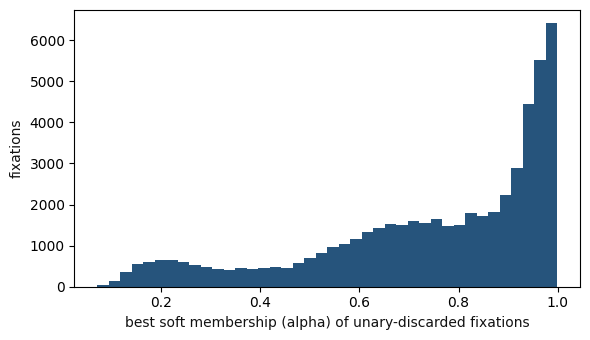

In [3]:
# ── Q1: what does unary assignment throw away? ─────────────────────────
orphans = [r for r in fix_rows if r[3] is None]
def best_alpha(r, key=4):
    return max(r[key].values()) if r[key] else 0.0

ba = np.array([best_alpha(r) for r in orphans])
dur = np.array([r[2] for r in orphans], dtype=float)
tot_dur = sum(r[2] for r in fix_rows)
for t in (0.25, 0.5, 0.75):
    frac = (ba >= t).mean()
    dfrac = dur[ba >= t].sum() / tot_dur
    print(f'unary-discarded fixations with best PAI >= {t:.2f}: {frac:.1%} of orphans '
          f'({dur[ba>=t].sum()/1000:.0f}s dwell, {dfrac:.1%} of corpus dwell)')
print(f'orphans with zero soft membership (true off-AOI): {(ba < ALPHA_FLOOR).mean():.1%}')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(ba, bins=40, color='#26547c')
ax.set_xlabel('best soft membership (alpha) of unary-discarded fixations', color='#111111')
ax.set_ylabel('fixations', color='#111111')
plt.tight_layout()
plt.savefig('plot_nb35_orphan_recovery.png', dpi=150)
plt.show()


In [4]:
# ── Q2: peripheral influence matrix (duration-weighted) ────────────────
# For fixations hard-assigned to row type, duration-weighted mean SUMMED
# alpha on column-type AOIs other than the assigned one (dimensionless;
# sums over multiple neighbors can exceed 1 — memberships are per-AOI
# independent, not normalized). Diagonal = neighboring same-type AOIs
# (0.000 for singleton-per-trial types). The organic->ad cell is the
# 'peripheral ad exposure during organic reading' enrichment preview.
MAIN = ['organic', 'native_ad', 'dd_top', 'dd_right', 'image_pack', 'paa', 'knowledge_panel']
mass = defaultdict(lambda: defaultdict(float))
denom = defaultdict(float)
for tid, i, d, hard, soft, _ in fix_rows:
    if hard is None:
        continue
    ht = aoi_type[(tid, hard)]
    if ht not in MAIN:
        continue
    denom[ht] += d
    for idx, al in soft.items():
        if idx == hard:
            continue
        ct = aoi_type[(tid, idx)]
        if ct in MAIN:
            mass[ht][ct] += al * d

print(f"{'hard-assigned':<16}" + ''.join(f'{c[:9]:>10}' for c in MAIN))
M = np.zeros((len(MAIN), len(MAIN)))
for r_i, rt in enumerate(MAIN):
    line = f'{rt:<16}'
    for c_i, ct in enumerate(MAIN):
        v = mass[rt][ct] / denom[rt] if denom[rt] else 0.0
        M[r_i, c_i] = v
        line += f'{v:>10.3f}'
    print(line)

ad_on_organic = (mass['organic']['native_ad'] + mass['organic']['dd_top']) / denom['organic']
print(f'\nperipheral AD mass during organic-assigned dwell: {ad_on_organic:.3f} '
      f'(duration-weighted mean summed alpha, dimensionless)')


hard-assigned      organic native_ad    dd_top  dd_right image_pac       paa knowledge
organic              1.966     0.293     0.183     0.092     0.159     0.072     0.058
native_ad            1.060     0.815     0.157     0.148     0.085     0.027     0.042
dd_top               1.015     0.186     0.000     0.000     0.086     0.036     0.003
dd_right             2.306     0.990     0.000     0.000     0.152     0.081     0.193
image_pack           1.779     0.303     0.131     0.087     0.002     0.036     0.042
paa                  2.460     0.201     0.177     0.069     0.127     0.000     0.032
knowledge_panel      2.433     0.432     0.020     0.290     0.112     0.037     0.000

peripheral AD mass during organic-assigned dwell: 0.476 (duration-weighted mean summed alpha, dimensionless)


In [5]:
# ── Sensitivity: boundary vs literal vertex OGD ────────────────────────
bb = np.array([best_alpha(r, 4) for r in orphans])
vv = np.array([best_alpha(r, 5) for r in orphans])
print('orphan recovery (best alpha >= 0.5):')
print(f'  boundary OGD: {(bb >= 0.5).mean():.1%}')
print(f'  vertex OGD:   {(vv >= 0.5).mean():.1%}')
# vertex form inside large AOIs: alpha at AOI center of a typical organic box
demo = {'x': 0, 'y': 0, 'width': 586, 'height': 132}
demo['cx'] = 293; demo['cy'] = 66
a_center_v = pai(293, 66, demo, ogd_vertex)
print(f'  vertex-form alpha at the CENTER of a 586x132 organic box: {a_center_v:.3f} '
      f'(boundary form: 1.000) — vertex OGD is degenerate for sparse rectangles')


orphan recovery (best alpha >= 0.5):
  boundary OGD: 83.9%
  vertex OGD:   52.0%
  vertex-form alpha at the CENTER of a 586x132 organic box: 1.000 (boundary form: 1.000) — vertex OGD is degenerate for sparse rectangles


In [6]:
# ── Q3: NB33 robustness under soft assignment ──────────────────────────
# Soft-weighted leftward fraction per type: each temporally-adjacent pair
# contributes to every AOI k with weight min(alpha_k(f1), alpha_k(f2));
# direction classified as in NB33 (horizontal-dominant, THETA, sweep excl).
fix_by_trial = defaultdict(list)
for r in fix_rows:
    fix_by_trial[r[0]].append(r)

wcount = defaultdict(lambda: {'reg': 0.0, 'fwd': 0.0})
for tid in trials:
    rows = fix_by_trial[tid]
    fixes = json.load(open(FIX_DIR / f'{tid}.json'))
    aois = {a['idx']: a for a in load_aois(tid)}
    for j in range(1, len(rows)):
        _, i0, d0, _, s0, _ = rows[j - 1]
        _, i1, d1, _, s1, _ = rows[j]
        f0, f1 = fixes[i0], fixes[i1]
        if f1['t'] - (f0['t'] + f0['d']) > MAX_GAP_MS:
            continue
        dx = f1['x'] - f0['x']; dy = f1['y'] - f0['y']
        if abs(dx) < abs(dy):
            continue
        for k in set(s0) & set(s1):
            a = aois[k]
            if (dx <= -SWEEP_FRAC * a['width']) and (dy > 0):
                continue
            w = min(s0[k], s1[k])
            if dx <= -THETA:
                wcount[a['type']]['reg'] += w
            elif dx >= THETA:
                wcount[a['type']]['fwd'] += w

# NB33 hard-assignment reference values (Key Claims / census table)
HARD_REF = {'organic': 0.402, 'paa': 0.381, 'knowledge_panel': 0.370,
            'native_ad': 0.442, 'image_pack': 0.459, 'dd_right': 0.453, 'dd_top': 0.522}
print(f"{'type':<18}{'soft left%':>11}{'hard left% (NB33)':>19}{'delta':>8}")
for t in MAIN:
    c = wcount[t]
    tot = c['reg'] + c['fwd']
    if tot < 50:
        continue
    soft_lf = c['reg'] / tot
    hard_lf = HARD_REF.get(t)
    d = soft_lf - hard_lf if hard_lf else float('nan')
    print(f"{t:<18}{soft_lf:>11.1%}{hard_lf:>19.1%}{d:>+8.1%}")

soft_rank = sorted((t for t in MAIN if wcount[t]['reg'] + wcount[t]['fwd'] >= 50),
                   key=lambda t: wcount[t]['reg'] / (wcount[t]['reg'] + wcount[t]['fwd']))
hard_rank = sorted(HARD_REF, key=HARD_REF.get)
from scipy.stats import spearmanr
common = [t for t in soft_rank if t in hard_rank]
rho_rank, _ = spearmanr([soft_rank.index(t) for t in common], [hard_rank.index(t) for t in common])
print(f'\nGate A type ordering, soft vs hard: Spearman rho = {rho_rank:+.2f}')


type               soft left%  hard left% (NB33)   delta
organic                 42.3%              40.2%   +2.1%
native_ad               43.4%              44.2%   -0.8%
dd_top                  46.7%              52.2%   -5.5%
dd_right                39.6%              45.3%   -5.7%
image_pack              43.5%              45.9%   -2.4%
paa                     41.4%              38.1%   +3.3%
knowledge_panel         42.7%              37.0%   +5.7%



Gate A type ordering, soft vs hard: Spearman rho = +0.54


In [7]:
# ── Key Claims candidates ──────────────────────────────────────────────
print('| ID | Claim | Value |')
print('|---|---|---|')
print(f"| K1 | Fixations unary-discarded (no AOI hit) | {(n-n_hard)/n:.1%} of {n:,} |")
print(f"| K2 | Discarded fixations with best PAI >= 0.5 (boundary OGD) | {(ba >= 0.5).mean():.1%} of orphans |")
print(f"| K3 | Peripheral ad mass during organic dwell (mean summed alpha) | {ad_on_organic:.3f} |")
print(f"| K4 | Vertex-OGD alpha at center of 586x132 box | {a_center_v:.3f} (degenerate; boundary form required for rects) |")
og = wcount['organic']
print(f"| K5 | Organic leftward fraction, soft-weighted | {og['reg']/(og['reg']+og['fwd']):.1%} (hard: 40.2%) |")
print(f"| K6 | Gate A type ordering, soft vs hard | rho={rho_rank:+.2f} |")


| ID | Claim | Value |
|---|---|---|
| K1 | Fixations unary-discarded (no AOI hit) | 22.8% of 234,339 |
| K2 | Discarded fixations with best PAI >= 0.5 (boundary OGD) | 83.9% of orphans |
| K3 | Peripheral ad mass during organic dwell (mean summed alpha) | 0.476 |
| K4 | Vertex-OGD alpha at center of 586x132 box | 1.000 (degenerate; boundary form required for rects) |
| K5 | Organic leftward fraction, soft-weighted | 42.3% (hard: 40.2%) |
| K6 | Gate A type ordering, soft vs hard | rho=+0.54 |


### Caveats

- **Abstract-only implementation.** The opacity function (α = 1 − OGD/OCD,
  clipped) and the boundary-distance OGD are documented assumptions; absolute
  α values may differ from the published PAI by a monotone reshaping. Census
  fractions at fixed thresholds and rank-order comparisons are the robust
  outputs. Verify against the paper when available (in review, same ETTAC
  session as the pupil-lfhf submission).
- **Vertex-OGD degeneracy** (K4) is a property of sparse rectangular AOIs, not
  a flaw in PAI as designed for dense polygonal meshes — but it means SERP-scale
  adoption needs the boundary form; raise with Duchowski before citing.
- Soft membership here is per-AOI independent (not normalized across AOIs);
  overlapping skirts double-count by design, matching the paper's per-AOI
  opacity framing.
- Calibration error (~20–40 px) inflates both the orphan pool and its
  recovered fraction symmetrically; K2 should not be read as pure peripheral
  vision — it is peripheral vision plus tracker error, inseparable at this
  precision.
- `[LAB]`-only.
